# Gene Model Characteristics

Genes with multiple long-read isoforms can differ in *where* the variation happens: at the transcription start site (TSS), in the exon/intron structure, or at the polyadenylation site (PAS). This tutorial introduces IsoTools functions that summarize this structural variation per gene and quantify transcript usage with entropy.

This tutorial assumes you have run the tutorial on [transcriptome reconstruction](03_transcriptome_reconstruction.html) already, and prepared the transcriptome pkl file "demo_isotools.pkl" based on the [demonstration data set](https://nc.molgen.mpg.de/cloud/index.php/s/Mf2zMePGBzFWFk8).

In [1]:
from isotools import Transcriptome
import logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)
logger = logging.getLogger('isotools')
# some GENCODE gene names/ids are shared across multiple genes; suppress the resulting
# lookup-ambiguity warnings for this demo (use the gene id instead of the name to avoid them)
logger.addFilter(lambda record: 'is ambiguous' not in record.getMessage())
import numpy as np
from isotools.plots import plot_str_var_number, triangle_plot
import matplotlib.pyplot as plt

path='demonstration_dataset'
transcriptome=Transcriptome.load(f'{path}/demo_isotools.pkl')

INFO:loading transcriptome from demonstration_dataset/demo_isotools.pkl


In [2]:
groups = transcriptome.groups()
group_colors = {'GM12878': '#f28e2b', 'K562': 'rebeccapurple'}
groups

{'GM12878': ['GM12878_a', 'GM12878_b', 'GM12878_c'],
 'K562': ['K562_a', 'K562_b', 'K562_c']}

In [3]:
sample_idx = {s: i for i, s in enumerate(transcriptome.samples)}

## Access genes by name or id
[Gene objects](../isotoolsAPI.html?highlight=isotools.Gene#isotools-gene) can be retrieved from the transcriptome object using the square bracket operator. This works with both the gene name and gene id. The gene object contains all information of the gene, like the coverage and the list of transcripts, which in turn contain the list of exons, comparison with reference annotation and much more. 

In [4]:
gene=transcriptome['ENSG00000104312.8']
if gene==transcriptome['RIPK2']:
    print('found the same gene by name and id')

#string representation
print(gene)
# obtain the sum coverage over all transcripts and samples
total_cov=gene.coverage.sum()
print(f"{total_cov} reads in total")

found the same gene by name and id
Gene RIPK2 chr8:89757805-89791064(+), 4 reference transcripts, 52 expressed transcripts
920 reads in total


In [5]:
#This gene has 52 expressed transcripts, only 4 of them are in the reference.
#However, most are supported by few reads only
num_transcripts = sum([cov>total_cov *.01 for cov in gene.coverage.sum(0)])
print(f'{num_transcripts} transcripts contribute at least 1% to that gene')


7 transcripts contribute at least 1% to that gene


In [6]:
#lets look at the primary transcript
max_i=np.argmax(gene.coverage.sum(0))
max_contr=gene.coverage.sum(0)[max_i]
print(f'''The primary transcript is number {max_i}.
This transcript contributes {max_contr/total_cov:.2%}  ({max_contr}/{total_cov} reads)''')


The primary transcript is number 2.
This transcript contributes 40.33%  (371/920 reads)


In [7]:
#all the information for this transcript are stored in this dict:
primary=gene.transcripts[max_i]
print(f'\nThese are the infos for this transcript:')
for k,v in primary.items():
    print(f'{k}: {str(v)[:100]}{"..." if len(str(v))>100 else ""}')




These are the infos for this transcript:
exons: [[np.int64(89757791), 89758233], [89762828, 89762982], [89765340, 89765496], [89769771, 89769929], [...
strand: +
coverage: {'GM12878_a': 48, 'GM12878_b': 135, 'GM12878_c': 138, 'K562_a': 19, 'K562_b': 18, 'K562_c': 13}
TSS: {'GM12878_a': {89757763: 1, 89757766: 1, 89757778: 1, 89757782: 3, 89757783: 4, 89757784: 4, 8975778...
PAS: {'GM12878_a': {89790462: 3, 89791057: 3, 89790608: 5, 89790939: 3, 89790606: 3, 89790425: 1, 8979046...
annotation: (0, {'FSM': [1]})
TSS_unified: {'GM12878_a': {np.int64(89757791): 48}, 'GM12878_b': {np.int64(89757791): 135}, 'GM12878_c': {np.int...
PAS_unified: {'GM12878_a': {np.int64(89790462): 20, np.int64(89790982): 10, np.int64(89790605): 11, np.int64(8979...
direct_repeat_len: [3, 3, 4, 5, 7, 3, 5, 4, 6, 4]
downstream_A_content: 0.2
ORF: (np.int64(89758060), np.int64(89790416), {"5'UTR": np.int64(269), 'CDS': np.int64(1623), "3'UTR": np...


In [8]:
# this 'annotation' line reveals that it is a FSM with reference transcript nr 1:
# annotation: (0, {'FSM': [1]})

print(f'\nThe corresponding reference transcript: ')
for k,v in gene.ref_transcripts[primary["annotation"][1]["FSM"][0]].items():
    print(f'{k}: {str(v)[:100]}{"..." if len(str(v))>100 else ""}')


The corresponding reference transcript: 
transcript_id: ENST00000220751.5
transcript_type: protein_coding
transcript_name: RIPK2-201
transcript_support_level: 1
exons: [(89757815, 89758233), (89762828, 89762982), (89765340, 89765496), (89769771, 89769929), (89771740, ...
CDS: (89758060, 89790416)
downstream_A_content: 0.06666666666666667
ORF: (np.int64(89758060), np.int64(89790416), {"5'UTR": 245, 'CDS': 1623, "3'UTR": np.int64(648), 'start_...


We will restrict the following analyses to transcripts passing the `BALANCED` filter scheme (introduced in the [filtering tutorial](06_filtering.html#Filter-Queries-for-transcript-export)).

In [9]:
query_string = 'BALANCED'

## Structural variation: TSS, exon chain and PAS

[str_var_calculation](../isotoolsAPI.html?highlight=str_var_calculation#isotools.Transcriptome.str_var_calculation) quantifies, for each gene, how much of the observed transcript variation is due to distinct TSS positions, distinct exon chains, or distinct PAS positions. The three fractions sum to 1 and are visualized as simplex coordinates in a triangle plot: a gene close to a corner is dominated by that source of variation, while a gene in the center shows a mix of all three.

In [10]:
str_var_tab = transcriptome.str_var_calculation(groups=groups, query=query_string, strict_ec=0, strict_pos=15)
str_var_tab.head()

,gene_id,gene_name,GM12878_tss,GM12878_ec,GM12878_pas,K562_tss,K562_ec,K562_pas
0,ENSG00000104723.21,TUSC3,NaN,NaN,NaN,0.266667,0.466667,0.266667
1,ENSG00000172164.15,SNTB1,0.322581,0.193548,0.483871,NaN,NaN,NaN
2,IT_novel_01788,IT_novel_01788,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
3,ENSG00000147408.16,CSGALNACT1,0.333333,0.333333,0.333333,NaN,NaN,NaN
4,ENSG00000147485.13,PXDNL,0.333333,0.333333,0.333333,NaN,NaN,NaN


/scratch/local/claude-16752/-home-Ayalanbi-src/f7e6815a-e937-41c0-a67a-faab9beb3220/scratchpad/venv_tutorials/lib/python3.12/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


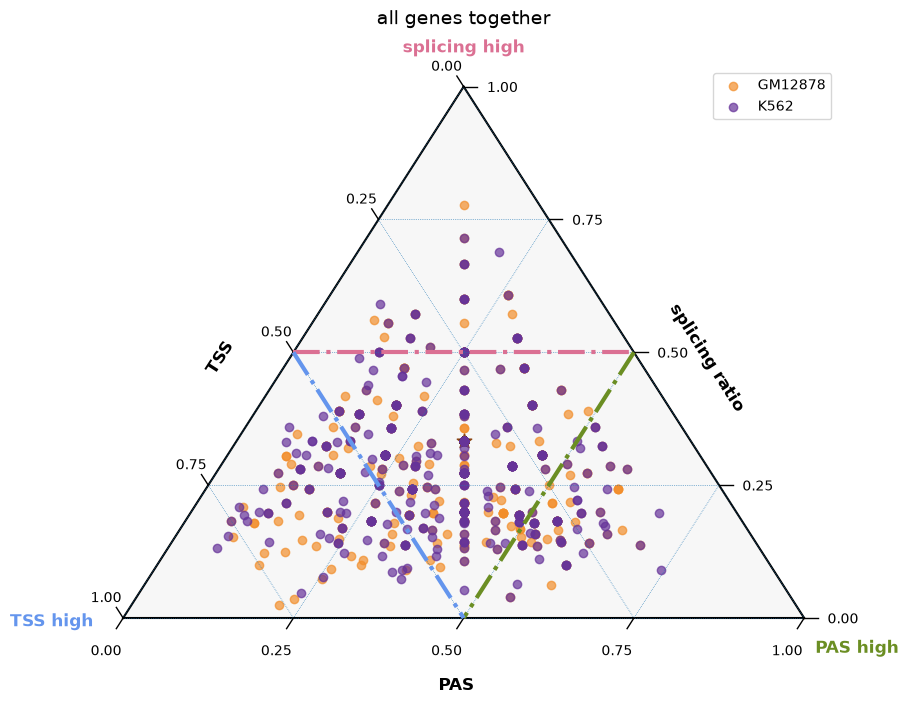

In [11]:
fig, ax = plt.subplots(1, figsize=(8, 7))
triangle_plot(str_var_tab, ax=ax, colors=group_colors, tax_title='all genes together')
fig.tight_layout()

Genes can change category between conditions. For example, *CA8* is close to the TSS/exon-chain mix in GM12878, but shifts towards PAS-dominated variation in K562.

Gene: CA8 (ENSG00000178538.10)


/scratch/local/claude-16752/-home-Ayalanbi-src/f7e6815a-e937-41c0-a67a-faab9beb3220/scratchpad/venv_tutorials/lib/python3.12/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


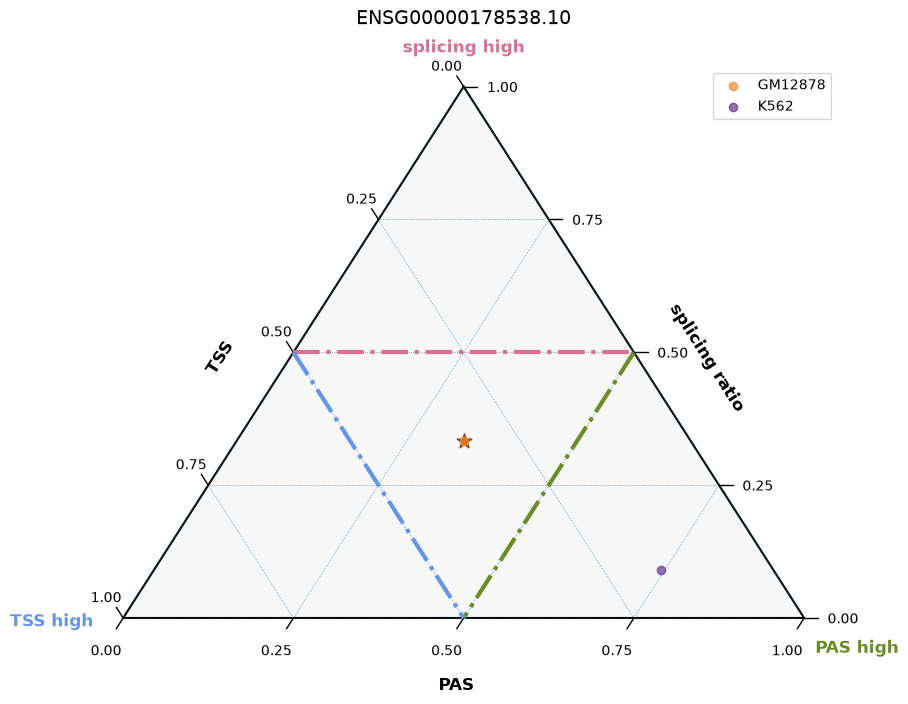

In [12]:
example_gene = 'ENSG00000178538.10'  # CA8
print(f'Gene: CA8 ({example_gene})')
fig, ax = plt.subplots(1, figsize=(8, 7))
triangle_plot(str_var_tab[str_var_tab['gene_id'] == example_gene], ax=ax, colors=group_colors, tax_title=example_gene)
fig.tight_layout()

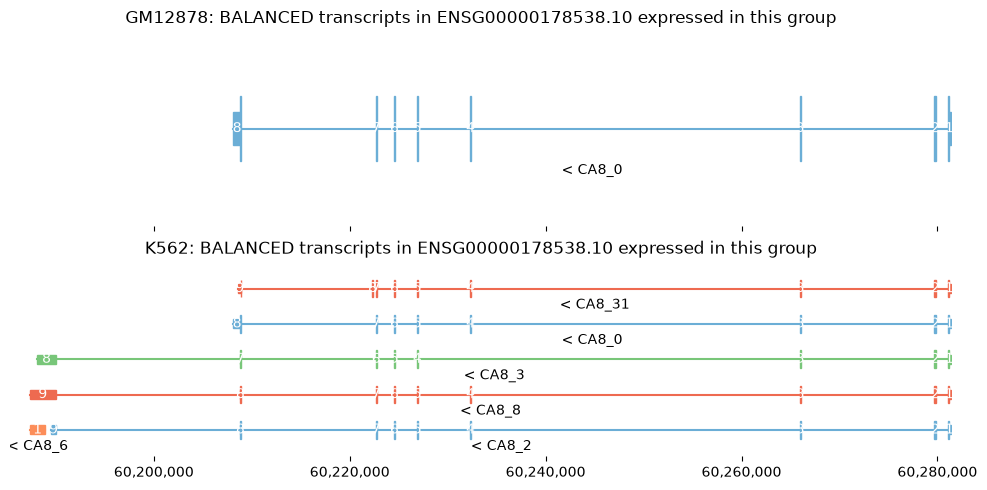

In [13]:
balanced_ids = transcriptome[example_gene].filter_transcripts(query=query_string)
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, (group_name, group_samples) in zip(axs, groups.items()):
    g_idx = [sample_idx[s] for s in group_samples]
    expressed_ids = [i for i in balanced_ids if transcriptome[example_gene].coverage[g_idx, i].sum() > 0]
    transcriptome[example_gene].gene_track(ax=ax, reference=False, query=query_string, select_transcripts=expressed_ids)
    ax.set_title(f'{group_name}: {query_string} transcripts in {example_gene} expressed in this group')
plt.tight_layout()
plt.show()

`str_var_calculation` can also report the raw counts of distinct TSSs, exon chains and PASs per gene (`count_number=True`), which [plot_str_var_number](../isotoolsAPI.html?highlight=plot_str_var_number#isotools.plots.plot_str_var_number) summarizes as a histogram per group.

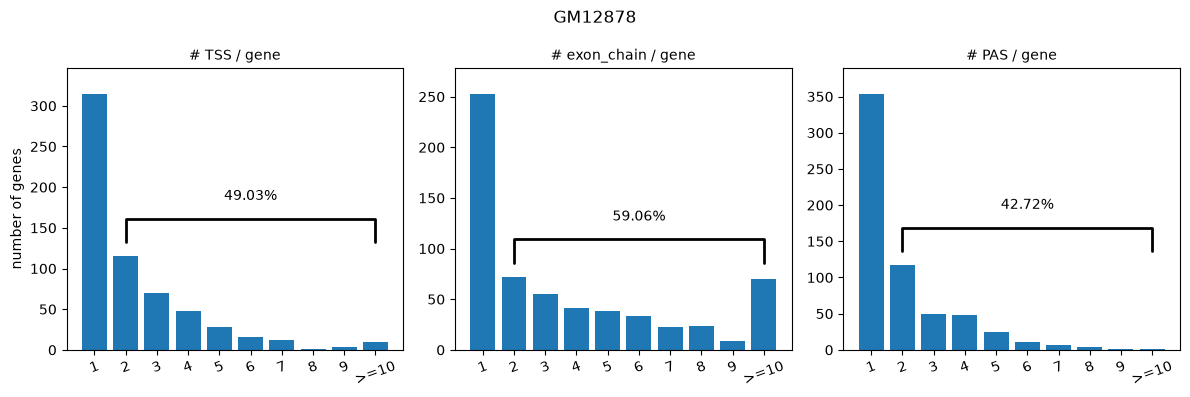

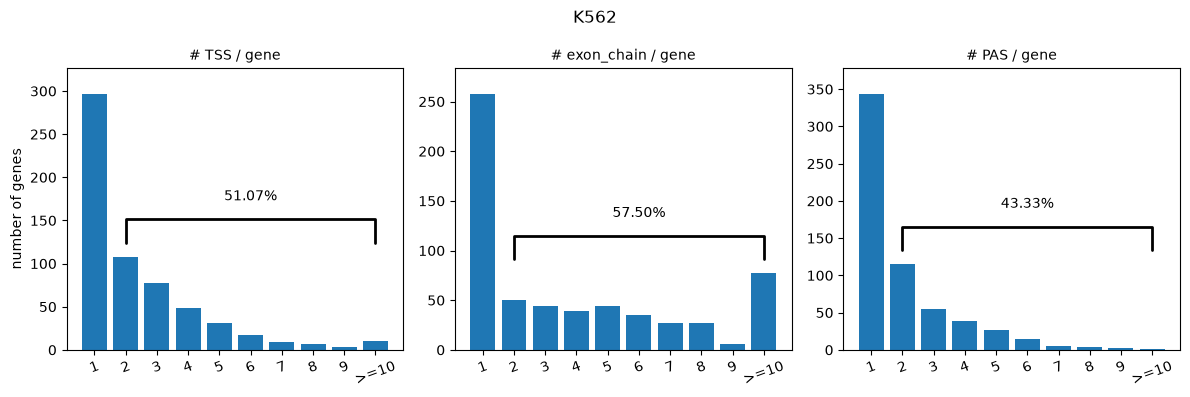

In [14]:
str_var_count = transcriptome.str_var_calculation(groups=groups, query=query_string, strict_ec=0, strict_pos=15, count_number=True)
for group_name in groups:
    fig = plot_str_var_number(str_var_count, group_name, fig_title=group_name)

## Transcript usage entropy

[entropy_calculation](../isotoolsAPI.html?highlight=entropy_calculation#isotools.Transcriptome.entropy_calculation) quantifies how evenly the reads of a gene are distributed across its transcripts. Relative entropy (`relative=True`, the default) scales the Shannon entropy to [0, 1] relative to the theoretical maximum for the number of transcripts observed in that gene: a value close to 0 means one isoform dominates, a value close to 1 means usage is spread evenly across isoforms.

In [15]:
entropy_tab = transcriptome.entropy_calculation(groups=groups, query=query_string, relative=True)
entropy_tab.head()

,gene_id,gene_name,GM12878_ntr,GM12878_rel_entropy,K562_ntr,K562_rel_entropy
0,ENSG00000104723.21,TUSC3,NaN,NaN,7,0.57385
1,ENSG00000172164.15,SNTB1,3,0.770561,NaN,NaN
2,IT_novel_01788,IT_novel_01788,1,NaN,1,NaN
3,ENSG00000147408.16,CSGALNACT1,1,NaN,NaN,NaN
4,ENSG00000147485.13,PXDNL,1,NaN,NaN,NaN


*CPQ* is a good example: usage is dominated by a single isoform in GM12878 (low entropy), but split between two isoforms in K562 (high entropy).


In [16]:
example_gene = 'ENSG00000104324.16'  # CPQ
print(f'Gene: CPQ ({example_gene})')
entropy_tab[entropy_tab['gene_id'] == example_gene]

Gene: CPQ (ENSG00000104324.16)


,gene_id,gene_name,GM12878_ntr,GM12878_rel_entropy,K562_ntr,K562_rel_entropy
200,ENSG00000104324.16,CPQ,2,0.222285,2,0.857148


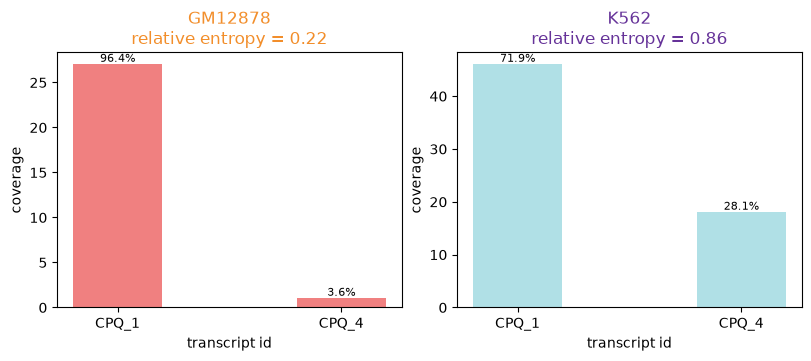

In [17]:
gene = transcriptome[example_gene]
balanced_ids = gene.filter_transcripts(query=query_string)
gene_entropy = entropy_tab.loc[entropy_tab['gene_id'] == example_gene].iloc[0]

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
for ax, (group_name, group_samples) in zip(axs, groups.items()):
    g_idx = [sample_idx[s] for s in group_samples]
    cov = gene.coverage[g_idx][:, balanced_ids].sum(0)
    expressed = [(tid, c) for tid, c in zip(balanced_ids, cov) if c > 0]
    total = sum(c for _, c in expressed)
    rel_entropy = gene_entropy[f'{group_name}_rel_entropy']

    # color bars by relative entropy: low = one isoform dominates, high = usage spread across isoforms
    if rel_entropy < 0.3:
        bar_color = 'lightcoral'
    elif rel_entropy > 0.7:
        bar_color = 'powderblue'
    else:
        bar_color = 'lightgrey'

    x = range(len(expressed))
    ax.bar(x, [c for _, c in expressed], color=bar_color, width=0.4)
    for j, (tid, c) in enumerate(expressed):
        ax.text(j, c, f'{c / total * 100:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f'{gene.name}_{tid}' for tid, _ in expressed])
    ax.set_ylabel('coverage')
    ax.set_xlabel('transcript id')
    ax.set_title(f'{group_name}\nrelative entropy = {rel_entropy:.2f}', color=group_colors[group_name])

plt.show()

## Conclusion

This tutorial introduced gene model characteristics beyond simple transcript counts:

* `str_var_calculation` and `triangle_plot` to localize structural variation to TSS, exon chain, or PAS
* `entropy_calculation` to quantify how evenly transcript usage is distributed within a gene
* `gene_track(colorbySqanti=True)` to color transcripts by their SQANTI structural category